In [49]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv('data/amazon_delivery.csv')

df.head()

df.info()

df.describe(include='all')

df.isnull().sum().sort_values(ascending=False)



<class 'pandas.DataFrame'>
RangeIndex: 43739 entries, 0 to 43738
Data columns (total 16 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Order_ID         43739 non-null  str    
 1   Agent_Age        43739 non-null  int64  
 2   Agent_Rating     43685 non-null  float64
 3   Store_Latitude   43739 non-null  float64
 4   Store_Longitude  43739 non-null  float64
 5   Drop_Latitude    43739 non-null  float64
 6   Drop_Longitude   43739 non-null  float64
 7   Order_Date       43739 non-null  str    
 8   Order_Time       43739 non-null  str    
 9   Pickup_Time      43739 non-null  str    
 10  Weather          43648 non-null  str    
 11  Traffic          43739 non-null  str    
 12  Vehicle          43739 non-null  str    
 13  Area             43739 non-null  str    
 14  Delivery_Time    43739 non-null  int64  
 15  Category         43739 non-null  str    
dtypes: float64(5), int64(2), str(9)
memory usage: 8.6 MB


Weather            91
Agent_Rating       54
Order_ID            0
Agent_Age           0
Store_Latitude      0
Store_Longitude     0
Drop_Latitude       0
Drop_Longitude      0
Order_Date          0
Order_Time          0
Pickup_Time         0
Traffic             0
Vehicle             0
Area                0
Delivery_Time       0
Category            0
dtype: int64

# Basic Cleaning

- Strip leading/trailing spaces
- Store time columns as strings
- Clean missing values

In [50]:
# Strip leading/trailing spaces from all string/object columns
str_cols = df.select_dtypes(include=["object", "string"]).columns
for col in str_cols:
    df[col] = df[col].astype(str).str.strip()

# Stored time columns as strings
time_cols = ["Order_Time", "Pickup_Time"]
for col in time_cols:
    if col in df.columns:
        df[col] = df[col].astype("string")

# Clean missing values
if "Weather" in df.columns:
    df["Weather"] = df["Weather"].fillna("Unknown")

if "Agent_Rating" in df.columns:
    median_rating = df["Agent_Rating"].median()
    df["Agent_Rating"] = df["Agent_Rating"].fillna(median_rating)

# Quick check after cleaning
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 43739 entries, 0 to 43738
Data columns (total 16 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Order_ID         43739 non-null  str    
 1   Agent_Age        43739 non-null  int64  
 2   Agent_Rating     43739 non-null  float64
 3   Store_Latitude   43739 non-null  float64
 4   Store_Longitude  43739 non-null  float64
 5   Drop_Latitude    43739 non-null  float64
 6   Drop_Longitude   43739 non-null  float64
 7   Order_Date       43739 non-null  str    
 8   Order_Time       43739 non-null  string 
 9   Pickup_Time      43739 non-null  string 
 10  Weather          43739 non-null  str    
 11  Traffic          43739 non-null  str    
 12  Vehicle          43739 non-null  str    
 13  Area             43739 non-null  str    
 14  Delivery_Time    43739 non-null  int64  
 15  Category         43739 non-null  str    
dtypes: float64(5), int64(2), str(7), string(2)
memory usage: 8.5 MB


# Feature Engineering

- Identify delay from order placed to order pickup
- Calculate distance using Haversine formula. This is done to get a
  real world approximation. 

In [51]:
# Compute pickup delay in minutes
order_ts = pd.to_datetime(df["Order_Date"].astype(str).str.strip() + " " + df["Order_Time"].astype(str).str.strip(), errors="coerce")
pickup_ts = pd.to_datetime(df["Order_Date"].astype(str).str.strip() + " " + df["Pickup_Time"].astype(str).str.strip(), errors="coerce")

df["pickup_delay"] = (pickup_ts - order_ts).dt.total_seconds() / 60

# Utilize Haversine formula to calculate distance between pickup and delivery locations
def calculate_distance(lat1, lon1, lat2, lon2):
    # Convert degrees to radians
    lat1, lon1, lat2, lon2 = map(np.radians, [lat1, lon1, lat2, lon2])
    dlat = lat2 - lat1
    dlon = lon2 - lon1
    a = np.sin(dlat/2)**2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon/2)**2
    c = 2 * np.arctan2(np.sqrt(a), np.sqrt(1-a))
    return 6371 * c  

# New column for distance from store to drop location
df["distance"] = df.apply(
    lambda row: calculate_distance(
        row["Store_Latitude"],
        row["Store_Longitude"],
        row["Drop_Latitude"],
        row["Drop_Longitude"],
    ),
    axis=1,
)

display(df.head())

,Order_ID,Agent_Age,Agent_Rating,Store_Latitude,Store_Longitude,Drop_Latitude,Drop_Longitude,Order_Date,Order_Time,Pickup_Time,Weather,Traffic,Vehicle,Area,Delivery_Time,Category,pickup_delay,distance
0,ialx566343618,37,4.9,22.745049,75.892471,22.765049,75.912471,2022-03-19,11:30:00,11:45:00,Sunny,High,motorcycle,Urban,120,Clothing,15.0,3.025149
1,akqg208421122,34,4.5,12.913041,77.683237,13.043041,77.813237,2022-03-25,19:45:00,19:50:00,Stormy,Jam,scooter,Metropolitian,165,Electronics,5.0,20.183530
2,njpu434582536,23,4.4,12.914264,77.678400,12.924264,77.688400,2022-03-19,08:30:00,08:45:00,Sandstorms,Low,motorcycle,Urban,130,Sports,15.0,1.552758
3,rjto796129700,38,4.7,11.003669,76.976494,11.053669,77.026494,2022-04-05,18:00:00,18:10:00,Sunny,Medium,motorcycle,Metropolitian,105,Cosmetics,10.0,7.790401
4,zguw716275638,32,4.6,12.972793,80.249982,13.012793,80.289982,2022-03-26,13:30:00,13:45:00,Cloudy,High,scooter,Metropolitian,150,Toys,15.0,6.210138


# Data Quality Check

In [52]:
quality = pd.DataFrame({
    "metric": [
        "rows_total",
        "delivery_time_nulls", "delivery_time_nonpositive",
        "distance_nulls", "distance_negative",
        "pickup_delay_nulls", "pickup_delay_negative"
    ],
    "value": [
        len(df),
        df["Delivery_Time"].isna().sum(), (df["Delivery_Time"] <= 0).sum(),
        df["distance"].isna().sum(), (df["distance"] < 0).sum(),
        df["pickup_delay"].isna().sum(), (df["pickup_delay"] < 0).sum()
    ]
})

df_clean = df.copy()
df_clean = df_clean[df_clean["Delivery_Time"].notna() & (df_clean["Delivery_Time"] > 0)]
df_clean = df_clean[df_clean["distance"].notna() & (df_clean["distance"] >= 0)]

display(quality)

,metric,value
0,rows_total,43739
1,delivery_time_nulls,0
2,delivery_time_nonpositive,0
3,distance_nulls,0
4,distance_negative,0
5,pickup_delay_nulls,91
6,pickup_delay_negative,828


# Quantify overall delivery time efficiency

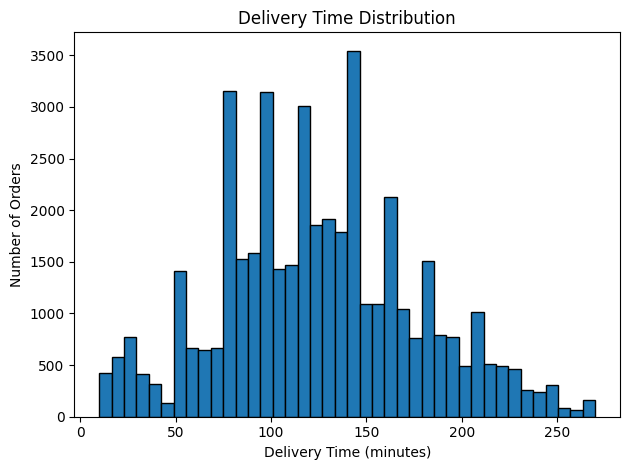

,distance_bin_km,orders,avg_time,median_time
0,"(1.0, 2.0]",3935,102.018297,100.0
1,"(2.0, 3.0]",506,103.112648,100.0
2,"(3.0, 5.0]",7281,107.339926,105.0
3,"(5.0, 8.0]",7859,116.695763,120.0
4,"(8.0, 12.0]",8349,128.669062,130.0
5,"(12.0, 20.0]",13588,141.754931,140.0
6,"(20.0, 50.0]",2033,141.722577,140.0


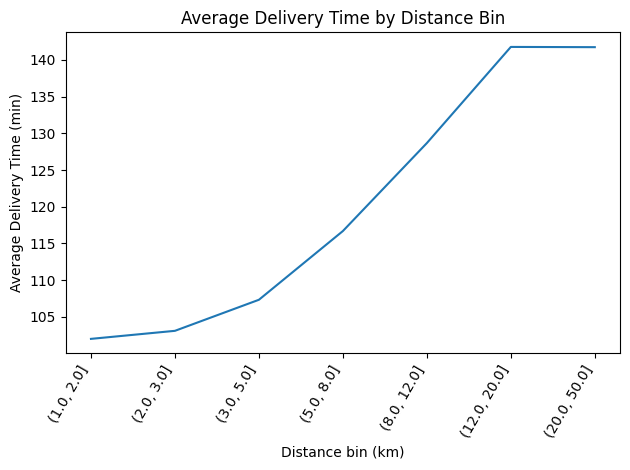

In [53]:
plt.figure()
plt.hist(df_clean["Delivery_Time"], bins=40, edgecolor="black")
plt.title("Delivery Time Distribution")
plt.xlabel("Delivery Time (minutes)")
plt.ylabel("Number of Orders")
plt.tight_layout()
plt.show()

df_clean["distance_bin_km"] = pd.cut(
    df_clean["distance"],
    bins=[0,1,2,3,5,8,12,20,50],
    include_lowest=True
)

dist_summary = (df_clean.groupby("distance_bin_km")
                .agg(orders=("Order_ID","count"),
                     avg_time=("Delivery_Time","mean"),
                     median_time=("Delivery_Time","median"))
                .reset_index())

display(dist_summary)

plt.figure()
plt.plot(dist_summary["distance_bin_km"].astype(str), dist_summary["avg_time"])
plt.title("Average Delivery Time by Distance Bin")
plt.xlabel("Distance bin (km)")
plt.ylabel("Average Delivery Time (min)")
plt.xticks(rotation=60, ha="right")
plt.tight_layout()
plt.show()


# Identify key factors that impact delivery time

Agent_Age       0.254618
pickup_delay    0.047235
distance       -0.001864
Agent_Rating   -0.289855
Name: Delivery_Time, dtype: float64

Traffic
Jam       147.758980
High      129.424115
Medium    126.839669
NaN       120.670330
Low       101.354557
Name: Delivery_Time, dtype: float64

Weather
Cloudy        138.286773
Fog           136.570833
Windy         123.658037
Sandstorms    123.238509
Stormy        123.211825
Unknown       120.670330
Sunny         103.664453
Name: Delivery_Time, dtype: float64

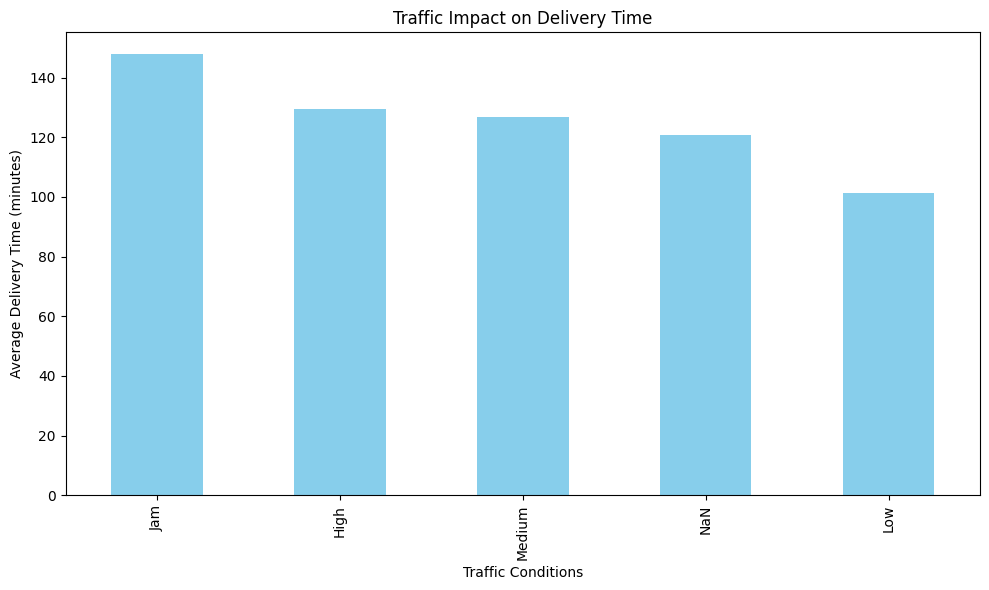

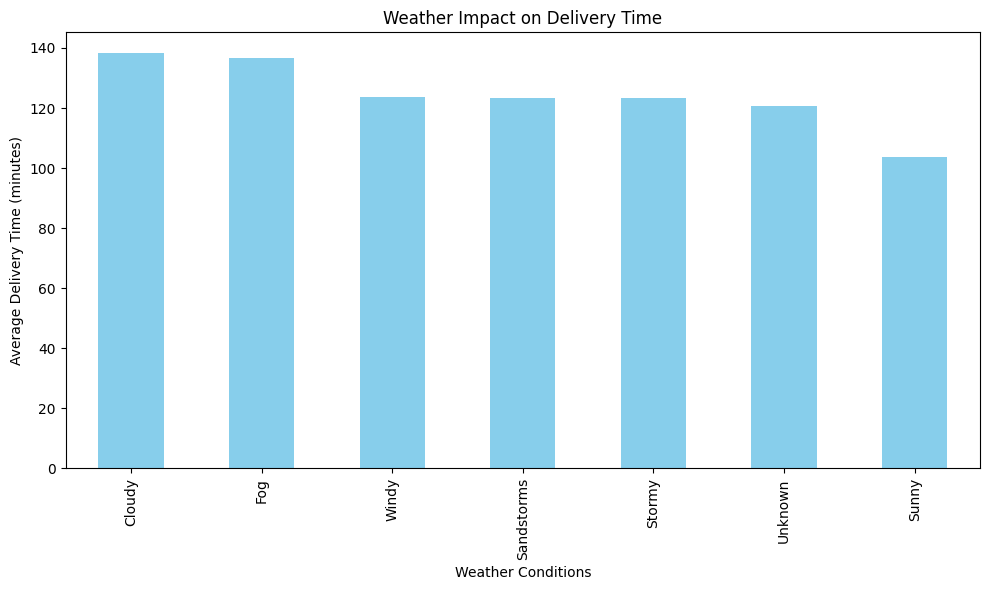

In [54]:
num_cols = ["distance", "pickup_delay", "Agent_Age", "Agent_Rating"]
correlation = df_clean[num_cols + ["Delivery_Time"]].corr()
driver_strength = correlation["Delivery_Time"][num_cols].sort_values(ascending=False)
display(driver_strength)

# Analyze traffic and weather effects on delivery time
traffic_effects = df_clean.groupby("Traffic")["Delivery_Time"].mean().sort_values(ascending=False)
weather_effects = df_clean.groupby("Weather")["Delivery_Time"].mean().sort_values(ascending=False)

display(traffic_effects)
display(weather_effects)

# Bar plot for traffic effects
plt.figure(figsize=(10, 6))
traffic_effects.plot(kind="bar", color="skyblue")
plt.title("Traffic Impact on Delivery Time")
plt.xlabel("Traffic Conditions")
plt.ylabel("Average Delivery Time (minutes)")
plt.tight_layout()
plt.show()

# Bar plot for weather effects
plt.figure(figsize=(10, 6))
weather_effects.plot(kind="bar", color="skyblue")
plt.title("Weather Impact on Delivery Time")
plt.xlabel("Weather Conditions")
plt.ylabel("Average Delivery Time (minutes)")
plt.tight_layout()
plt.show()

# Find segments with constant high or low delivery times

In [55]:
segments = (df_clean.groupby(["Area", "Vehicle"]).agg(
    orders=("Order_ID", "count"),
    avg_time=("Delivery_Time", "mean"),
    median_time=("Delivery_Time", "median")
).reset_index().sort_values(by="avg_time", ascending=False))

print("Fastest segments:")
display(segments.head())
print("\nSlowest segments:")
display(segments.tail())

Fastest segments:


,Area,Vehicle,orders,avg_time,median_time
9,Semi-Urban,van,3,245.000000,245.0
7,Semi-Urban,motorcycle,140,238.535714,245.0
8,Semi-Urban,scooter,9,236.666667,240.0
1,Metropolitian,motorcycle,19360,135.274019,135.0
0,Metropolitian,bicycle,15,127.000000,125.0



Slowest segments:


,Area,Vehicle,orders,avg_time,median_time
4,Other,motorcycle,606,109.356436,105.0
6,Other,van,89,103.224719,95.0
12,Urban,van,824,101.991505,95.0
11,Urban,scooter,3506,101.801483,95.0
5,Other,scooter,443,98.022573,90.0


# Actionable Recommendations

- Traffic jams and high congestion add the most delay. Prioritize dynamic routing, time‑window optimization, and pre‑positioning of agents/vehicles to avoid known jammed corridors in peak hours.
- Metropolitan areas served by motorcycles and, to a lesser extent, bicycles consistently deliver faster than other segments. Use these routes as benchmarks and consider shifting volume from slower other van routes where feasible.
- Cloudy, fog, and stormy conditions materially increase delivery time. Introduce weather‑aware SLAs and buffer times, and consider proactive customer messaging and staffing adjustments on days with adverse forecasts.
- Semi‑urban segments show systematically higher delivery times. Review stop density, route design, and depot placement in these areas to reduce distance and idle time.
- Higher agent ratings correlate with shorter delivery times. Use best‑performing agents practices to inform training, and consider incentives tied to both punctuality and rating.
